# Capítulo 12 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 12. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Cp, sigma = 9.8, 1004.0, 5.67e-8
Omega, R_T = 7.292e-5, 6.371e6

## T1 — Relação de Margules

**Solução.** Duas massas com densidades $\rho_1 > \rho_2$ (fria embaixo, na cunha) e ventos geostróficos $U_1$, $U_2$ paralelos à frente. A pressão deve ser contínua na interface $z = x\tan\alpha$; derivando a continuidade de $P$ ao longo da interface e usando geostrofia em cada lado ($\partial P/\partial x = -\rho f U$ com o eixo $x$ transversal) e hidrostática ($\partial P/\partial z = -\rho g$):
$$\tan\alpha = \frac{f\,(\rho_1 U_1 - \rho_2 U_2)}{g\,(\rho_1 - \rho_2)}\;\simeq\; \frac{|f|\,\bar T\,\Delta U}{g\,\Delta T},$$
onde a última forma usa $\rho \propto 1/T$ (mesma $P$). A interface só é estacionária com salto de vento na direção da frente — sem cisalhamento não há frente inclinada em equilíbrio. ∎

In [2]:
# verificação simbólica da última passagem (rho ∝ 1/T)
f_, g_, T1, T2, U1, U2, Tm = sp.symbols('f g T_1 T_2 U_1 U_2 T_m', positive=True)
rho1, rho2 = 1/T1, 1/T2                     # constantes comuns cancelam
tanA = f_*(rho1*U1 - rho2*U2)/(g_*(rho1 - rho2))
# caso U1 = U - dU/2, U2 = U + dU/2, T1 = T - dT/2, T2 = T + dT/2, expandir em dT, dU
U, dU, T, dT = sp.symbols('U dU T dT', positive=True)
expr = tanA.subs({U1: U - dU/2, U2: U + dU/2, T1: T - dT/2, T2: T + dT/2})
serie = sp.series(sp.simplify(expr), dT, 0, 2).removeO()
display(sp.simplify(serie))
print('termo dominante: f*T*dU/(g*dT)  ✓ (o termo com U puro some se dT->0 com dU fixo? não —')
print('ele é o termo barotrópico f*U/g, inclinação da superfície isobárica; a FRENTE fica com f T dU/(g dT).')

f*(-T*dU + U*dT)/(dT*g)

termo dominante: f*T*dU/(g*dT)  ✓ (o termo com U puro some se dT->0 com dU fixo? não —
ele é o termo barotrópico f*U/g, inclinação da superfície isobárica; a FRENTE fica com f T dU/(g dT).


## T2 — Escala de tempo da gênese radiativa

In [3]:
# linearizando dT/dt = -eps*sigma*(T^4 - Ts^4)/(rho Cp H) em torno de Ts:
T_, Ts_, eps_, s_, rho_, Cp_, H_ = sp.symbols('T T_s epsilon sigma rho C_p H', positive=True)
rhs = -eps_*s_*(T_**4 - Ts_**4)/(rho_*Cp_*H_)
lin = sp.series(rhs, T_, Ts_, 2).removeO()
display(sp.simplify(lin))
tau = sp.simplify(-1/sp.diff(rhs, T_).subs(T_, Ts_))
display(sp.Eq(sp.Symbol('tau'), tau))
vals = {eps_: 0.85, s_: 5.67e-8, rho_: 1.2, Cp_: 1004.0, H_: 1000.0, Ts_: 248.0}
print(f'tau = {float(tau.subs(vals))/86400:.1f} dias — gênese de massa de ar leva ~1 semana,')
print('consistente com a EDO completa do Caso 1 e com os 3–14 dias do Stull.')

4*T_s**3*epsilon*sigma*(-T + T_s)/(C_p*H*rho)

Eq(tau, C_p*H*rho/(4*T_s**3*epsilon*sigma))

tau = 4.7 dias — gênese de massa de ar leva ~1 semana,
consistente com a EDO completa do Caso 1 e com os 3–14 dias do Stull.


## T3 — Frontogênese exponencial

**Solução.** Com $u = -ax$ e $T$ conservada, $\partial_t T = ax\,\partial_x T$. Derivando em $x$: $\partial_t(\partial_x T) = a\,\partial_x T + ax\,\partial_x^2 T$; na linha da frente ($x = 0$, máximo do gradiente) o segundo termo se anula e
$$\frac{d}{dt}|\partial_x T| = a\,|\partial_x T| \Rightarrow |\partial_x T| = |\partial_x T|_0\,e^{at}.$$
Dobra a cada $\ln 2/a \simeq 19$ h para $a = 10^{-5}$ s$^{-1}$ — frentes afiam em ~1–2 dias. ∎ (Verificação numérica abaixo.)

In [4]:
a = 1e-5
x = np.linspace(-2e6, 2e6, 4001)
ts = np.linspace(0, 48*3600, 25)
grads = [np.max(np.abs(np.gradient(285 - 8*np.tanh(x*np.exp(a*t)/6e5), x)))
         for t in ts]
taxa = np.polyfit(ts, np.log(grads), 1)[0]
print(f'taxa ajustada = {taxa:.3e} 1/s  vs  a = {a:.3e} 1/s  ✓')
print(f'tempo de dobra = {np.log(2)/taxa/3600:.1f} h')

taxa ajustada = 1.000e-05 1/s  vs  a = 1.000e-05 1/s  ✓
tempo de dobra = 19.3 h


## T4 — A dobra das isóbaras na frente

**Solução.** $P$ é contínua através da frente, mas $\nabla P$ não: o lado frio (denso) tem $|\partial P/\partial x|$ maior. Uma isóbara que chega à frente com inclinação dada muda de direção ao cruzar — sempre com o **bico apontando da baixa para a alta** (o "V" invertido das cartas). A frente ocupa um cavado: $P$ tem mínimo local na linha frontal, e por isso a pressão cai antes e sobe depois da passagem (meteograma do Caso 4). ∎

## T5 — Oclusão fria × quente

**Solução.** Na oclusão, a frente fria alcança a quente e o setor quente é erguido. Comparam-se as duas massas *frias*: a que avança (atrás da fria) e a que recua (à frente da quente).
- **Oclusão fria**: ar que avança é o mais frio → ele se enfia por baixo de tudo; a frente fria original continua no chão (comum em continentes de inverno).
- **Oclusão quente**: ar que avança é menos frio que o que recua → ele sobe por cima da cunha fria pré-existente; a frente quente original fica na superfície (comum perto de oceanos frios).
Critério prático: compare $\theta_w$ (conservada!) dos dois lados frios; o menor $\theta_w$ fica embaixo. ∎

---
## N1 — Varredura da gênese

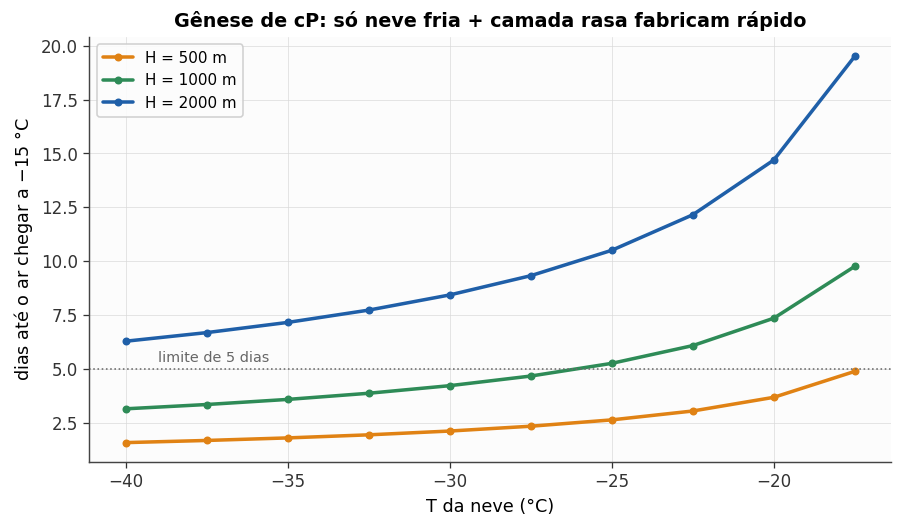

camada de 500 m sobre neve de -30 °C ou menos: massa pronta em < 5 dias;
camadas espessas (2 km) precisam de ~2 semanas — por isso a genese exige
anticiclone estacionario (subsidencia rasa + ceu limpo).


In [5]:
rho, eps = 1.2, 0.85
T0, alvo = 283.0, 258.15                  # ar inicial +10 °C; alvo -15 °C

def tempo_ate_alvo(T_sfc, H, dias_max=40):
    def f_(t, T):
        return -eps*sigma*(T**4 - T_sfc**4)/(rho*Cp*H)
    def evento(t, T):
        return T[0] - alvo
    evento.terminal, evento.direction = True, -1
    s = solve_ivp(f_, [0, dias_max*86400], [T0], events=evento, rtol=1e-8)
    return s.t_events[0][0]/86400 if s.t_events[0].size else np.nan

Tsfcs = 273.15 + np.arange(-40, -9, 2.5)
Hs = [500.0, 1000.0, 2000.0]
fig, ax = plt.subplots(figsize=(9, 4.8))
for H, cor in zip(Hs, [CORES['laranja'], CORES['verde'], CORES['azul']]):
    dias = [tempo_ate_alvo(Ts, H) for Ts in Tsfcs]
    ax.plot(Tsfcs - 273.15, dias, 'o-', ms=4, color=cor, label=f'H = {H:.0f} m')
ax.axhline(5, color=CORES['cinza'], ls=':', lw=1)
ax.text(-39, 5.3, 'limite de 5 dias', fontsize=9, color='#666666')
ax.set(xlabel='T da neve (°C)', ylabel='dias até o ar chegar a $-15$ °C',
       title='Gênese de cP: só neve fria + camada rasa fabricam rápido')
ax.legend()
plt.show()
print('camada de 500 m sobre neve de -30 °C ou menos: massa pronta em < 5 dias;')
print('camadas espessas (2 km) precisam de ~2 semanas — por isso a genese exige')
print('anticiclone estacionario (subsidencia rasa + ceu limpo).')

## N2 — A cunha de Margules em corte

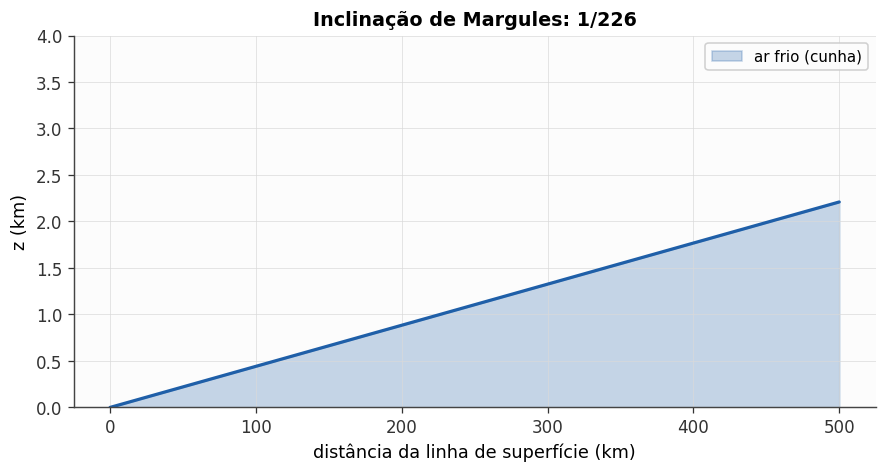

inclinacao = 1/226; a 500 km, a interface esta a 2210 m —
e por isso a nebulosidade da frente quente se estende por centenas de km.


In [6]:
f = 2*Omega*np.sin(np.deg2rad(-45))
dT, dU, T_med = 10.0, 15.0, 280.0
alpha = np.abs(f)*T_med*dU/(g*dT)
x = np.linspace(0, 500e3, 200)
z_int = alpha*x

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.fill_between(x/1e3, 0, z_int/1e3, color=CORES['azul'], alpha=0.25,
                label='ar frio (cunha)')
ax.plot(x/1e3, z_int/1e3, color=CORES['azul'], lw=2)
ax.set(xlabel='distância da linha de superfície (km)', ylabel='z (km)',
       title=f'Inclinação de Margules: 1/{1/alpha:.0f}'.replace('.', ','),
       ylim=(0, 4))
ax.legend()
plt.show()
print(f'inclinacao = 1/{1/alpha:.0f}; a 500 km, a interface esta a {alpha*500e3:.0f} m —')
print('e por isso a nebulosidade da frente quente se estende por centenas de km.')

## N3 — Deformação + rotação

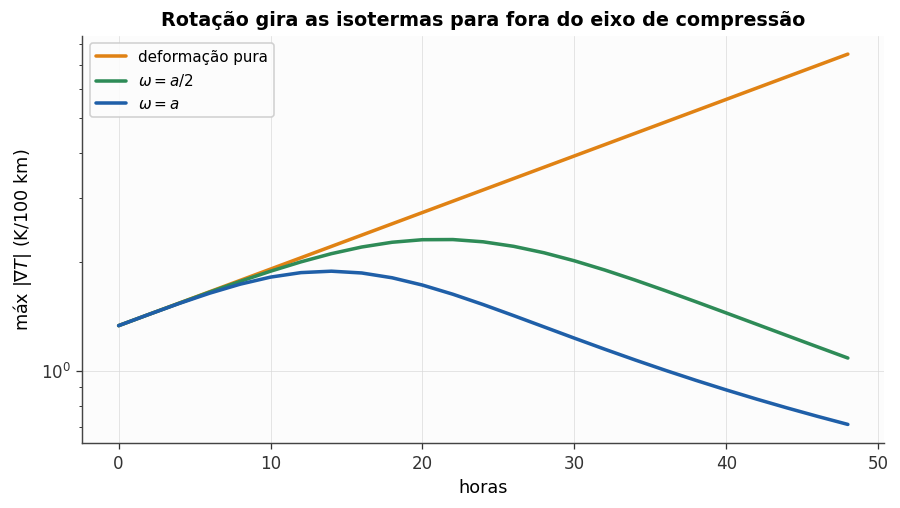

a rotacao NAO frontogeniza: ela gira o gradiente para fora do eixo de
compressao e reduz a taxa efetiva (com omega = a o crescimento quase para).


In [7]:
# advecção 2-D por trajetórias (integração regressiva analítica é chata com rotação;
# usamos marcadores lagrangianos e medimos o gradiente por ajuste)
def evolui_grad(a, omega, T_horas=48):
    n = 121
    x0 = np.linspace(-1e6, 1e6, n); y0 = np.zeros(n)
    def vel(t, s):
        x, y = s[:n], s[n:]
        return np.concatenate([-a*x - omega*y, a*y + omega*x])
    sol = solve_ivp(vel, [0, T_horas*3600], np.concatenate([x0, y0]),
                    t_eval=np.linspace(0, T_horas*3600, 25), rtol=1e-8)
    T_marc = 285 - 8*np.tanh(x0/6e5)          # etiqueta conservada de cada marcador
    grads = []
    for k in range(sol.t.size):
        x = sol.y[:n, k]
        ordem = np.argsort(x)
        # distância no plano entre marcadores vizinhos:
        y = sol.y[n:, k]
        ds = np.hypot(np.diff(x[ordem]), np.diff(y[ordem]))
        grads.append(np.max(np.abs(np.diff(T_marc[ordem]))/np.maximum(ds, 1.0)))
    return sol.t, np.array(grads)

a = 1e-5
fig, ax = plt.subplots(figsize=(9, 4.6))
for omega, cor, nome in [(0.0, CORES['laranja'], 'deformação pura'),
                          (0.5e-5, CORES['verde'], '$\\omega = a/2$'),
                          (1e-5, CORES['azul'], '$\\omega = a$')]:
    t, gr = evolui_grad(a, omega)
    ax.semilogy(t/3600, gr*1e5, color=cor, label=nome)
ax.set(xlabel='horas', ylabel='máx $|\\nabla T|$ (K/100 km)',
       title='Rotação gira as isotermas para fora do eixo de compressão')
ax.legend()
plt.show()
print('a rotacao NAO frontogeniza: ela gira o gradiente para fora do eixo de')
print('compressao e reduz a taxa efetiva (com omega = a o crescimento quase para).')

## N4 — Meteograma da frente quente

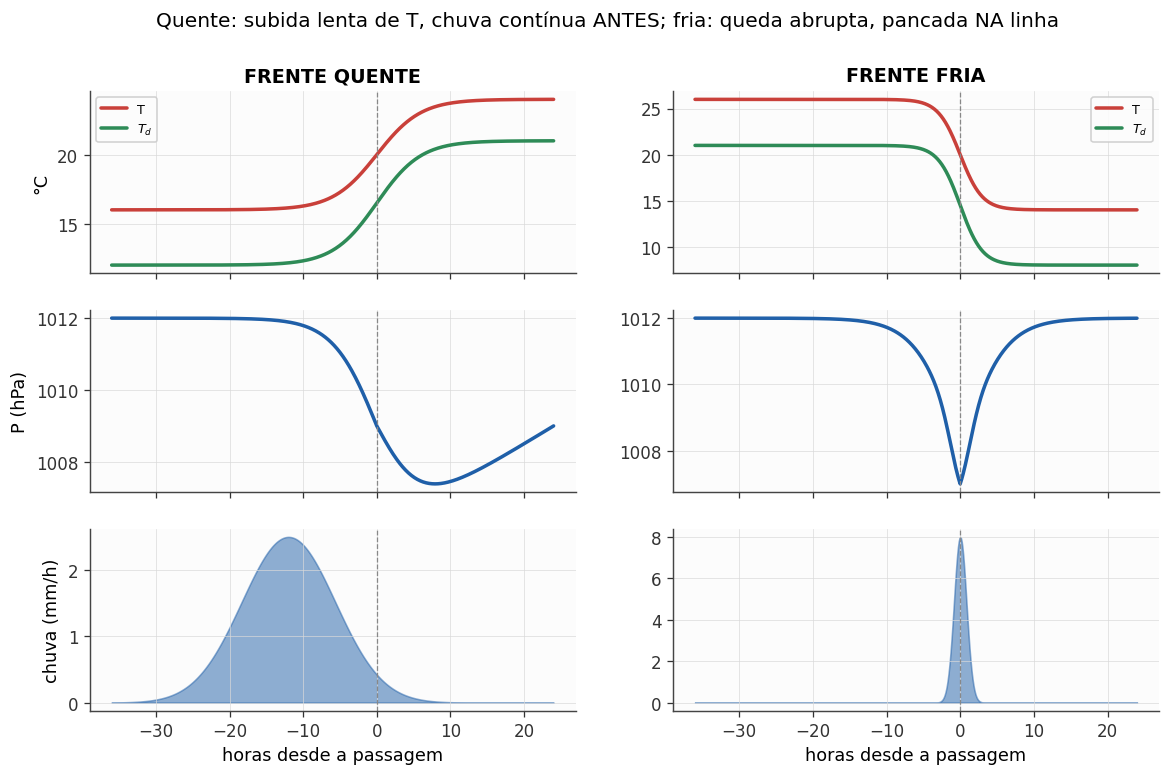

quente: nebulosidade estratiforme adiantada (cunha rasa de Margules, N2);
fria: cunha ingreme -> conveccao na linha; contraste didatico completo.


In [8]:
t = np.linspace(-36, 24, 601)
sq = 1/(1 + np.exp(-t/3))                      # transição LENTA (quente)
sf = 1/(1 + np.exp(-t/1.5))                    # fria (Caso 4), p/ comparação

fig, axs = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
# coluna 0: quente | coluna 1: fria
casos = [
 ('FRENTE QUENTE', sq, 16 + 8*sq, 12 + 9*sq, 1012 - 6*sq + 3*np.maximum(t, 0)/24,
  np.mod(360 + 50 + 60*sq, 360), 2.5*np.exp(-((t + 12)/9)**2)),
 ('FRENTE FRIA', sf, 26 - 12*sf, 21 - 13*sf, 1008 + 4*np.abs(np.tanh(t/6)) - np.exp(-(t/2)**2),
  np.mod(360 + 20 + 200*sf, 360), 8*np.exp(-(t/1.2)**2))]
for col, (nome, s, T_, Td_, P_, dir_, ch_) in enumerate(casos):
    axs[0, col].plot(t, T_, color=CORES['vermelho'], label='T')
    axs[0, col].plot(t, Td_, color=CORES['verde'], label='$T_d$')
    axs[0, col].set_title(nome); axs[0, col].legend(fontsize=8)
    axs[1, col].plot(t, P_, color=CORES['azul'])
    axs[2, col].fill_between(t, ch_, color=CORES['azul'], alpha=0.5)
    for r in range(3):
        axs[r, col].axvline(0, color='#888888', lw=0.8, ls='--')
axs[0, 0].set_ylabel('°C'); axs[1, 0].set_ylabel('P (hPa)')
axs[2, 0].set_ylabel('chuva (mm/h)')
for col in range(2):
    axs[2, col].set_xlabel('horas desde a passagem')
fig.suptitle('Quente: subida lenta de T, chuva contínua ANTES; fria: queda abrupta, pancada NA linha')
plt.show()
print('quente: nebulosidade estratiforme adiantada (cunha rasa de Margules, N2);')
print('fria: cunha ingreme -> conveccao na linha; contraste didatico completo.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*